# OCT multi-class stratification 
Experiment with OCT as matching model!

# Models trained on unmatched original cohort. 

In [1]:
import sys
print(f"Python version: {sys.version}")
import json
import logging
import csv
import gzip
import re
import pandas as pd
import numpy as np
from functools import reduce
from pyspark.sql.types import StringType,DecimalType,DoubleType,IntegerType
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml.feature import VectorAssembler, Bucketizer
import matplotlib.pyplot as plt
import pyspark.sql.functions as F
import pyspark.sql.types as T
from pyspark.sql import SparkSession,Row
from pyspark import SparkConf
import plotly.express as px
import plotly.graph_objects as go
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number, col
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# -----------------------------------------------------------------------------
# INITIALIZE LOGGING
# -----------------------------------------------------------------------------
f = '%(asctime)-15s %(levelname)-8s %(message)s'
logger = logging.getLogger(__name__)
logger.setLevel("DEBUG")
logging.basicConfig(format=f)


from IPython.core.magic import register_cell_magic

# -----------------------------------------------------------------------------
# start_spark
# -----------------------------------------------------------------------------
def start_spark(
    driver_memory="100g",
    storage_fraction=0.5,
    num_nodes=10,
):
    """Initialize spark

    Arguments:
        driver_memory: Maximum heap size for the Spark driver Java
            virtual machine.
        storage_fraction: Controls what portion of Spark's unified
            memory is reserved for storage (i.e., caching/persisting data
            and broadcast variables), as a fraction of the total
            execution + storage memory pool.
            If you cache/persist a lot of data, and you're evicting
            data too early, you might increase this value (e.g. 0.6 or 0.7).
            Conversely, if your job is shuffle-heavy and fails due to
            memory pressure, you might decrease it (e.g. 0.3).
        num_nodes: How many concurrent threads to use while running
            in "local mode" (i.e. in a single machine instead of a cluster).
            Use '*' to use all cores, or an integer > 0 for a specific
            number of threads.
    """

    conf = SparkConf().setAppName("My_Application")
    conf.set("spark.driver.memory", driver_memory)
    conf.set("spark.memory.storageFraction", str(storage_fraction))
    conf.setMaster(f"local[{num_nodes}]")

    spark = SparkSession.builder.config(conf=conf).getOrCreate()
    spark.sparkContext.setLogLevel('WARN')

    return spark


Python version: 3.11.0 (main, Jun 13 2025, 14:48:45) [Clang 16.0.0 (clang-1600.0.26.6)]


In [2]:

spark = start_spark(num_nodes=10)
#spark.stop()

  
@register_cell_magic
def spark_sql(line, cell):
    result = spark.sql(cell)
    result.show(n=1000)


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/30 13:57:33 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/10/30 13:57:33 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [3]:
df_2018 = spark.read.format("parquet").load( "0917_2017_18_with_2017_cost.parquet")
df_og = df_2018.toPandas()
df_og.shape,df_og.columns

25/10/30 13:57:35 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


((33542, 95),
 Index(['ENROLID', 'annual_cost_2017', 'highcost_gt_50000_2017',
        'highcost_gt_75000_2017', 'highcost_gt_100000_2017',
        'highcost_gt_200000_2017', 'highcost_gt_300000_2017',
        'highcost_gt_400000_2017', 'highcost_gt_500000_2017', 'INCOME_LEVEL',
        'annual_cost_2018_deflated', 'highcost_gt_50000', 'highcost_gt_75000',
        'highcost_gt_100000', 'highcost_gt_200000', 'highcost_gt_300000',
        'highcost_gt_400000', 'highcost_gt_500000', 'AGEGRP', 'SEX', 'REGION',
        'has_Hypertension', 'has_Type_2_Diabetes', 'has_Anemia',
        'has_Hyperlipidemia', 'has_Acute_Kidney_Failure',
        'has_Hyperparathyroidism', 'has_Kidney_Transplant',
        'has_Vitamin_D_Deficiency', 'has_Long-term_Drug_Therapy',
        'has_Hypothyroidism', 'has_Sleep_Apnea', 'stage_2017', 'util_2017',
        'Antihyperlipidemic Drugs, NEC (THRCLS_53)',
        'Cardiac, Beta Blockers (THRCLS_51)',
        'Cardiac, Calcium Channel (THRCLS_52)',
        'Psychot

In [4]:
sum(df_og.annual_cost_2017.isna())


0

# Feature groups, define high cost and train-test-split

In [5]:

import importlib
import model_pipeline
importlib.reload(model_pipeline)
import model_IAI
importlib.reload(model_IAI)

from model_IAI import train_oct_with_feature_names, finetune_oct


In [6]:
BIN_FLAG_COLUMNS = model_pipeline.get_bin_flag_columns(df_og) +['lab_monitoring_adherent','nephrology_consult_adherent','early_nephrology_referral']
STAGE_COLUMNS = [col for col in df_og.columns if "stage" in col.lower()]
#["stage_2017",'2017Q1_max_ckd_stage','2017Q2_max_ckd_stage', '2017Q3_max_ckd_stage','2017Q4_max_ckd_stage']
CAT_COLUMNS = df_og.select_dtypes(include=["object","category"]).columns.tolist()
TRUE_NUM_COLUMNS = model_pipeline.get_true_num_columns(df_og,CAT_COLUMNS)+[ 'util_2017', 'total_increasing_quarters_2017'
, 'total_lab_tests', 'ckd_visit_count', 'quarters_with_labs', 'nephrology_visit_count', 'days_to_nephrology','MEDIAN_INCOME']
COST_COLUMNS = [col for col in df_og.columns if 
            "cost" in col.lower() or 
             "quarterly" in col.lower()  or "increasing" in col.lower()
             ]
UTILIZATION_COLUMNS = [col for col in df_og.columns if "claims" not in col.lower() ] + ['util_2017']
print("categorical cols: ", CAT_COLUMNS)
print("stage cols: ", STAGE_COLUMNS)
print(COST_COLUMNS)
leftover_cols = [
    c for c in df_og.columns 
    if c not in CAT_COLUMNS and c not in TRUE_NUM_COLUMNS and c not in STAGE_COLUMNS and c not in BIN_FLAG_COLUMNS 
]

print(f"Number of leftover columns: {len(leftover_cols)}")
print(leftover_cols, df_og.shape)  # preview first 50

categorical cols:  ['ENROLID', 'INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'cost_pattern_2017', 'cost_stability_2017', 'lab_monitoring_intensity']
stage cols:  ['stage_2017', '2017Q1_max_ckd_stage', '2017Q2_max_ckd_stage', '2017Q3_max_ckd_stage', '2017Q4_max_ckd_stage']
['annual_cost_2017', 'highcost_gt_50000_2017', 'highcost_gt_75000_2017', 'highcost_gt_100000_2017', 'highcost_gt_200000_2017', 'highcost_gt_300000_2017', 'highcost_gt_400000_2017', 'highcost_gt_500000_2017', 'annual_cost_2018_deflated', 'highcost_gt_50000', 'highcost_gt_75000', 'highcost_gt_100000', 'highcost_gt_200000', 'highcost_gt_300000', 'highcost_gt_400000', 'highcost_gt_500000', '2017Q1_ckd_cost', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_direct_ckd_cost', '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost', '2017Q4_ckd_cost', '2017Q4

In [7]:
def make_cost_stratum_3class(df):
    # Default to low-cost (class 0)
    cost_stratum = pd.Series(0, index=df.index)
    # Moderate (class 1): 50k+ to 100k
    cost_stratum[(df['highcost_gt_50000'] == 1) & (df['highcost_gt_100000'] == 0)] = 1
    # Emergent high cost (class 2): 100k to 200k
    cost_stratum[(df['highcost_gt_100000'] == 1) & (df['highcost_gt_200000'] == 0)] = 2
    # High cost (class 2): 200k+
    cost_stratum[df['highcost_gt_200000'] == 1] = 3
    return cost_stratum

# Add the new column to your data
df_og['cost_stratum_2018'] = make_cost_stratum_3class(df_og)
print(df_og["cost_stratum_2018"].value_counts(dropna=False))


cost_stratum_2018
0    29401
1     1800
2     1398
3      943
Name: count, dtype: int64


In [8]:
cutoff_columns = [col for col in df_og.columns if col.startswith('highcost_gt_')]

feature_cols = [c for c in df_og.columns
              if c not in  (['annual_cost_2017','annual_cost_2018_deflated',"ENROLID", "cost_stratum_2018"] 
              + cutoff_columns)]    # keep only predictors excl. cost of 2018 and cutoff of 2017
numeric_cols = df_og[feature_cols + ["cost_stratum_2018"]].select_dtypes(include=["number"]).columns
corrs = df_og[numeric_cols].corr()["cost_stratum_2018"].abs().sort_values(ascending=False)
# Columns to drop
high_corr_cols = corrs[corrs > 0.5].index.tolist()
# Remove the target column itself, if present
high_corr_cols = [col for col in high_corr_cols if col != "cost_stratum_2018"]
# Final filtered feature set
feature_cols = [col for col in feature_cols if col not in high_corr_cols]
print("High corr features dropped from prediction columns: ",high_corr_cols)

# 2) split
train_ids, test_ids,train_pd,test_pd = model_pipeline.train_test_split_enrol(df_og,
    target_col = "cost_stratum_2018",test_size=0.3,verbose=False,random_state=123)
print(train_pd.shape,test_pd.shape)
print("Feature cols:", len(feature_cols))


High corr features dropped from prediction columns:  []
(23479, 96) (10063, 96)
Feature cols: 78


# Pre-balance

In [55]:
import numpy as np
import pandas as pd
from typing import Tuple

def pre_balance_undersample(df: pd.DataFrame,
                           target_column: str = 'highcost_gt_100000',
                           protect_column: str = 'highcost_gt_50000',
                           sampling_ratio: float = 1/20,
                           random_state: int = 42) -> pd.DataFrame:
    """
    Simple pre-balancing undersampler for binary classification.
    Protects all samples where protect_column == 1 from being discarded.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Input dataframe with binary target column
    target_column : str
        Binary target column for defining minority/majority classes (default: 'highcost_gt_100000')
    protect_column : str
        Column defining samples to always keep (default: 'highcost_gt_50000')
    sampling_ratio : float
        Ratio of minority class size to majority class size after sampling
        (e.g., 1/20 = 0.05 means majority class will be 20x the minority class)
    random_state : int
        Random state for reproducible sampling
        
    Returns:
    --------
    pd.DataFrame : Undersampled dataframe
    """
    print(f"Pre-balancing undersampling with ratio 1:{1/sampling_ratio:.0f}")
    
    # Split based on target column
    minority_class = df[df[target_column] > 0].copy()  # highcost_gt_100000 == 1
    majority_class = df[df[target_column] == 0].copy()  # highcost_gt_100000 == 0
    
    # From majority class, separate protected vs unprotected samples
    protected_samples = majority_class[majority_class[protect_column] == 1].copy()  # highcost_gt_50000 == 1
    unprotected_samples = majority_class[majority_class[protect_column] == 0].copy()  # highcost_gt_50000 == 0
    
    print(f"Original: {len(minority_class):,} target minority, {len(majority_class):,} target majority")
    print(f"  Protected samples in majority: {len(protected_samples):,}")
    print(f"  Unprotected samples in majority: {len(unprotected_samples):,}")
    
    # Calculate target sample size for majority class
    target_majority_size = int(len(minority_class) / sampling_ratio)
    
    # Always keep all protected samples, sample from unprotected
    remaining_slots = target_majority_size - len(protected_samples)
    remaining_slots = max(0, remaining_slots)  # Can't be negative
    
    if remaining_slots > len(unprotected_samples):
        print(f"Warning: Need {remaining_slots:,} samples but only {len(unprotected_samples):,} unprotected available")
        sampled_unprotected = unprotected_samples.copy()
    else:
        np.random.seed(random_state)
        sampled_unprotected = unprotected_samples.sample(n=remaining_slots, random_state=random_state)
    
    # Combine: ALL minority + ALL protected + sampled unprotected
    sampled_majority = pd.concat([protected_samples, sampled_unprotected], ignore_index=True)
    undersampled_df = pd.concat([minority_class, sampled_majority], ignore_index=True)
    undersampled_df = undersampled_df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    
    print(f"After undersampling: {len(minority_class):,} target minority, {len(sampled_majority):,} target majority")
    print(f"  (includes {len(protected_samples):,} protected samples)")
    print(f"Total size: {len(df):,} → {len(undersampled_df):,} ({len(undersampled_df)/len(df)*100:.1f}%)")
    
    return undersampled_df


## TODO: change sampling ratio. ONLY ON THE ORIGINAL TRAIN DATA
df_prebalanced = pre_balance_undersample(
    df=train_pd,
    target_column='cost_stratum_2018',  # Target for minority/majority classification
    protect_column='highcost_gt_50000',  # Samples to always keep
    sampling_ratio=1/10,
    random_state=42
)

Pre-balancing undersampling with ratio 1:10
Original: 2,899 target minority, 20,580 target majority
  Protected samples in majority: 0
  Unprotected samples in majority: 20,580
After undersampling: 2,899 target minority, 20,580 target majority
  (includes 0 protected samples)
Total size: 23,479 → 23,479 (100.0%)


# OCT M1 stratification
2) Binary OCT on all Train data (model M1), using information of (t-1) year to predict year t costs (H(t) or L(t)), with bias towards H(t-1) [or we can use high stage here]

3) In each leaf of the tree M1, divide the population in L vs H based on year t costs (truth): H(t) and L(t)

In [56]:
import oct_stratifier
importlib.reload(oct_stratifier)
from oct_stratifier import train_stratifier_oct,train_stratifier_oct_tuned


# After your pre-balancing step:
pipeline_results = train_stratifier_oct_tuned(
    df_prebalanced=df_prebalanced,
    stratification_cols=[col for col in feature_cols if col not in COST_COLUMNS],
    CAT_COLUMNS=CAT_COLUMNS,
    TRUE_NUM_COLUMNS=TRUE_NUM_COLUMNS,
    target="highcost_gt_200000"

)

# Access results:
df_M1 = pipeline_results['df_with_leaves']
model = pipeline_results['model']
preprocessor = pipeline_results['preprocessor']
feature_names = pipeline_results['feature_names']

model

Using full dataset for tuning: 23,479 rows
Target distribution (tuning base):
  Class 0: 22,819 (97.2%)
  Class 1: 660 (2.8%)
Total parameter combinations before sampling: 48

[1/48] Evaluating params: {'max_depth': 5, 'minbucket': 100, 'cp': 0.0005}
→ Building preprocessor:
   • OneHotEncoder on: ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'lab_monitoring_intensity']
   • StandardScaler on: ['2017Q1_ckd_claims', '2017Q2_ckd_claims', '2017Q3_ckd_claims', '2017Q4_ckd_claims', 'util_2017', 'total_lab_tests', 'nephrology_visit_count']
→ Building preprocessor:
   • OneHotEncoder on: ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'lab_monitoring_intensity']
   • StandardScaler on: ['2017Q1_ckd_claims', '2017Q2_ckd_claims', '2017Q3_ckd_claims', '2017Q4_ckd_claims', 'util_2017', 'total_lab_tests', 'nephrology_visit_count']
→ Building preprocessor:
   • OneHotEncoder on: ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'lab_monitoring_intensity']
   • StandardScaler on: ['2017Q1_ckd_claims', '2017Q2_c

Fitted OptimalTreeClassifier:
  1) Split: total_lab_tests < -0.4016
    2) Predict: 0 (98.89%), [8194,92], 8286 points, error 0.0111
    3) Split: has_Kidney_Transplant < 0.5
      4) Split: 2017Q3_ckd_claims < 2.558
        5) Predict: 0 (97.10%), [13176,394], 13570 points, error 0.02903
        6) Split: stage_2017 < 4.5
          7) Predict: 0 (84.23%), [267,50], 317 points, error 0.1577
          8) Predict: 1 (59.66%), [48,71], 119 points, error 0.4034
      9) Predict: 0 (95.53%), [1134,53], 1187 points, error 0.04465

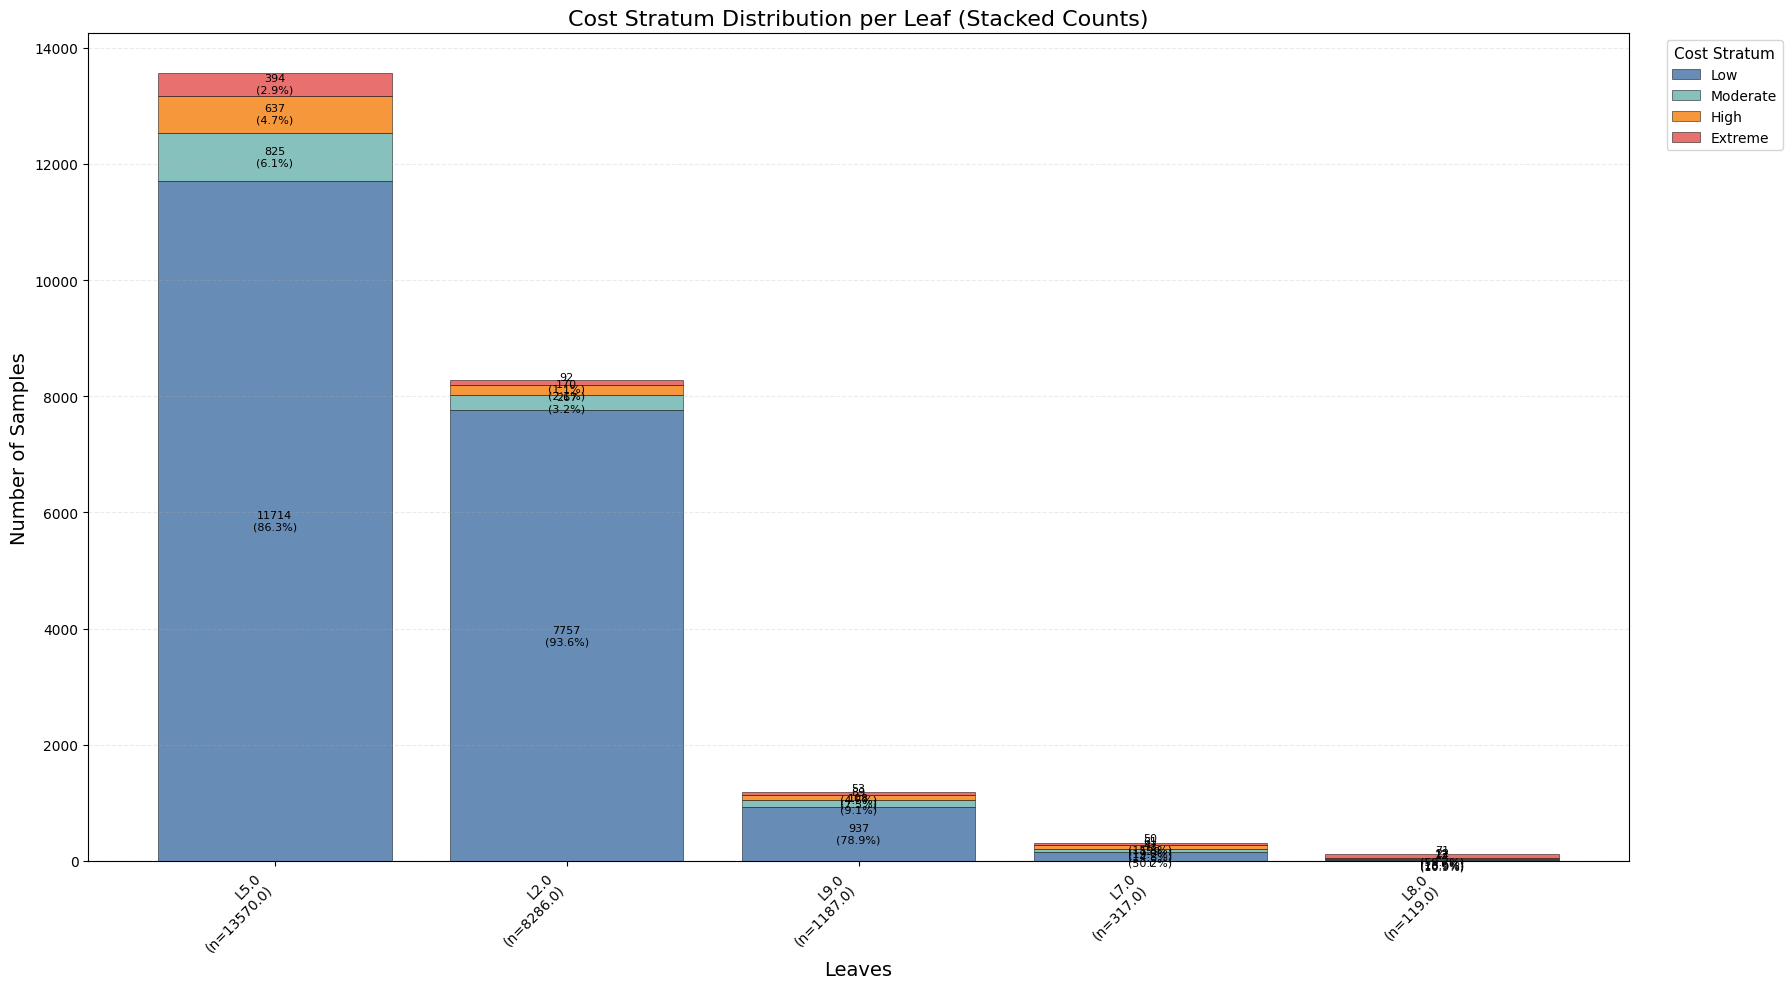


LEAF STRATUM SUMMARY
Overall class distribution across all leaves:
  Stratum 0 (Low): 20580 (87.7%)
  Stratum 1 (Moderate): 1260 (5.4%)
  Stratum 2 (High): 979 (4.2%)
  Stratum 3 (Extreme): 660 (2.8%)

Dominant stratum frequency among selected leaves:
  Stratum 0 (Low): 4 leaves (80.0%)
  Stratum 3 (Extreme): 1 leaves (20.0%)

Mean predicted vs actual rates (overall):
 Stratum    Label  Actual_Rate  Pred_Rate
       0      Low        0.877      0.995
       1 Moderate        0.054      0.005
       2     High        0.042      0.000
       3  Extreme        0.028      0.000


In [57]:
import oct_leaf_analysis
importlib.reload(oct_leaf_analysis)
labels = {0: 'Low', 1: 'Moderate', 2: 'High', 3: 'Extreme'}
colors = {0: '#4C78A8', 1: '#72B7B2', 2: '#F58518', 3: '#E45756'}
leaf_stats_df = oct_leaf_analysis.visualize_leaf_cost_distributions_4class(
    df_M1,
    strata_labels=labels,
    strata_colors=colors
)



In [58]:
bigleaf = df_M1[df_M1["leaf_assignment"]==5]
bigleaf

,ENROLID,annual_cost_2017,highcost_gt_50000_2017,highcost_gt_75000_2017,highcost_gt_100000_2017,highcost_gt_200000_2017,highcost_gt_300000_2017,highcost_gt_400000_2017,highcost_gt_500000_2017,INCOME_LEVEL,...,cost_stability_2017,total_lab_tests,lab_monitoring_adherent,lab_monitoring_intensity,nephrology_visit_count,nephrology_consult_adherent,early_nephrology_referral,cost_stratum_2018,predicted_cost_stratum,leaf_assignment
0,3214941701,814.70,0,0,0,0,0,0,0,2,...,highly_volatile,15,1,High,9,1,1,0,0,5
4,130443901,1445.45,0,0,0,0,0,0,0,2,...,highly_volatile,19,1,High,9,1,0,0,0,5
5,3280230901,24989.68,0,0,0,0,0,0,0,0,...,moderate,74,1,High,30,1,0,2,0,5
7,3966032101,52879.13,1,0,0,0,0,0,0,3,...,highly_volatile,13,1,High,8,1,0,0,0,5
12,925552201,43359.62,0,0,0,0,0,0,0,0,...,highly_volatile,24,1,High,20,1,0,0,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23470,4196335201,1136.30,0,0,0,0,0,0,0,2,...,moderate,13,1,High,7,1,0,0,0,5
23471,1267346702,764.33,0,0,0,0,0,0,0,2,...,moderate,19,1,High,6,1,1,0,0,5
23473,3062558901,1895.41,0,0,0,0,0,0,0,0,...,moderate,8,1,Moderate,5,1,1,0,0,5
23477,2478068501,54169.85,1,0,0,0,0,0,0,2,...,highly_volatile,32,1,High,37,1,0,2,0,5


In [61]:
import oct_stratifier
importlib.reload(oct_stratifier)
from oct_stratifier import train_stratifier_oct,train_stratifier_oct_tuned

# After your pre-balancing step:
pipeline_results2 = train_stratifier_oct(
    df_prebalanced=bigleaf,
    stratification_cols=[col for col in feature_cols if col not in COST_COLUMNS],
    CAT_COLUMNS=CAT_COLUMNS,
    TRUE_NUM_COLUMNS=TRUE_NUM_COLUMNS,
    #target="highcost_gt_200000",
    target="cost_stratum_2018",
)


model2 = pipeline_results2["model"]
model2



 Training binary OCT M1 on all train data with 13,570 samples
------------------------------------------------------------
Using 42 stratification features for M1
M1 training set target cost_stratum_2018 distribution:
  Class 0: 11,714 samples (86.3%)
  Class 1: 825 samples (6.1%)
  Class 2: 637 samples (4.7%)
  Class 3: 394 samples (2.9%)

Training M1 OCT...
Using preset params:  9 100 1e-05
→ Building preprocessor:
   • OneHotEncoder on: ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'lab_monitoring_intensity']
   • StandardScaler on: ['2017Q1_ckd_claims', '2017Q2_ckd_claims', '2017Q3_ckd_claims', '2017Q4_ckd_claims', 'util_2017', 'total_lab_tests', 'nephrology_visit_count']
✓ OCT training completed successfully
✓ Processed training data shape: (13570, 50)
✓ Feature names: 50
✓ Leaf assignments completed
✓ Number of unique leaves: 4
✓ Number of unique predicted strata: 2
Total unique leaf-class combinations: 4


/Users/cat2510/my_projects/oct_stratifier.py:181: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_prebalanced['leaf_assignment'] = leaf_assignments
/Users/cat2510/my_projects/oct_stratifier.py:182: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_prebalanced['predicted_cost_stratum'] = cost_stratum_predictions


Fitted OptimalTreeClassifier:
  1) Split: util_2017 < 0.6633
    2) Predict: 0 (90.94%), [10279,484,369,171], 11303 points, error 0.0906
    3) Split: 2017Q4_ckd_claims < 1.443
      4) Predict: 0 (69.12%), [1191,251,169,112], 1723 points, error 0.3088
      5) Split: 2017Q4_max_ckd_stage < 4.5
        6) Predict: 0 (51.26%), [224,78,71,64], 437 points, error 0.4874
        7) Predict: 3 (43.93%), [20,12,28,47], 107 points, error 0.5607

# In-Leaf Undersampling

In [62]:
import balancing_functions.optimal_match_lexicographic
importlib.reload(balancing_functions.optimal_match_lexicographic)
from balancing_functions.optimal_match_lexicographic import LexicographicCaseControlResampler
def create_lexicographic_undersampled_data(pipeline_results, target_col, 
                                         undersampling_ratio=5.0, 
                                         balance_tolerance=0.7, max_controls_per_case = 1,
                                         verbose=True):
    """
    Parameters:
    -----------
    balance_tolerance : float
        If majority_size - minority_size <= balance_tolerance * minority_size, 
        skip undersampling for this leaf
    pipeline_results : dict
        Results from your create_cost_strata_pipeline()
    target_col : str
        Target column (e.g., 'high_cost_2018')
    undersampling_ratio : float
        Target majority:minority ratio
    use_adaptive_filtering : bool
        Whether to use adaptive filtering fallback
    verbose : bool
        Print progress information
    
    Returns:
    --------
    pd.DataFrame : Undersampled dataset
    """
    
    # Extract data from pipeline results
    df_with_leaves = pipeline_results['df_with_leaves']
    feature_cols = pipeline_results['stratification_cols']
    
    # Initialize lexicographic matcher
    matcher = LexicographicCaseControlResampler(
        matching_method="ortools",
        random_state=42,
        binary_group=target_col,
        uid_col="ENROLID"  
    )
    
    print(f"=== LEXICOGRAPHIC OPTIMIZATION UNDERSAMPLING ===")
    print(f"Original dataset: {len(df_with_leaves):,} samples")
    
    # Process each leaf
    unique_leaves = df_with_leaves['leaf_assignment'].unique()
    print(f"Processing {len(unique_leaves)} OCT leaves...")
    
    undersampled_parts = []
    
    for leaf_id in sorted(unique_leaves):
        leaf_df = df_with_leaves[
            df_with_leaves['leaf_assignment'] == leaf_id
        ].copy()
            
        # Skip small leaves
        if len(leaf_df) < 30:
            if verbose:
                print(f"Leaf {leaf_id}: Skipped (too small: {len(leaf_df)} samples)")
            continue
        
        # Check class distribution
        class_counts = leaf_df[target_col].value_counts()
        if len(class_counts) < 2:
            if verbose:
                print(f"Leaf {leaf_id}: Skipped (single class)")
            continue
            
        majority_class = class_counts.index[0]
        minority_class = class_counts.index[1] 
        n_majority = class_counts[majority_class]
        n_minority = class_counts[minority_class]

        if n_majority <= 300:
            disable_lexicographic = True
            undersampling_ratio = 1

        else:
            disable_lexicographic = False
        
        # NEW: Check if leaf is already nearly balanced
        imbalance = n_majority - n_minority
        balance_threshold = balance_tolerance * n_minority
        
        if imbalance <= balance_threshold:
            if verbose:
                print(f"Leaf {leaf_id}: Already balanced (n_maj - n_min: {imbalance} ≤ 0.9*n_min {balance_threshold:.1f}), keeping as-is")
                print(f"  Counts: {n_majority} majority, {n_minority} minority")
            undersampled_parts.append(leaf_df)
            continue
        
        # Calculate target
        target_majority = n_minority * undersampling_ratio
        if target_majority >= n_majority:
            undersampled_parts.append(leaf_df)
            print(f"Skipping undersampling: Target majority value larger than existing majority samples")
            print(f"  Counts: {n_majority} majority, {n_minority} minority")

            continue
        
        # Separate classes
        majority_df = leaf_df[leaf_df[target_col] == majority_class].copy()
        minority_df = leaf_df[leaf_df[target_col] == minority_class].copy()
        
        if verbose:
            print(f"\nLeaf {leaf_id}: {n_majority} majority → {target_majority} (keeping {n_minority} minority)")
        
        try:
        
            matched_result = matcher.ortools_optimization_matching(
                dfA=minority_df,
                dfB=majority_df,
                target_controls=target_majority, 
                target_cases=n_minority,
                exclude_cols_matching=['leaf_assignment', 'cost_stratum']+COST_COLUMNS,
                verbose=verbose,
                max_controls_per_case=max_controls_per_case, 
                top_k_factor=700,
                similarity_threshold=0.5,
                disable_lexicographic=disable_lexicographic
            )
        
            undersampled_parts.append(matched_result)
            
            if verbose:
                final_counts = matched_result[target_col].value_counts()
                print(f"  Result: {dict(final_counts)}")
                
        except Exception as e:
            if verbose:
                print(f"  Optimization failed: {e}")
                print(f"  Keeping leaf as-is due to optimization failure")
            undersampled_parts.append(leaf_df)  # Fallback to original
    
    # Combine results
    if undersampled_parts:
        final_result = pd.concat(undersampled_parts, ignore_index=True)
        
        print(f"\n=== FINAL RESULTS ===")
        print(f"Original: {len(df_with_leaves):,} samples")
        print(f"Undersampled: {len(final_result):,} samples")
        print(f"Reduction: {(1-len(final_result)/len(df_with_leaves))*100:.1f}%")
        
        original_dist = df_with_leaves[target_col].value_counts()
        final_dist = final_result[target_col].value_counts()
        print(f"Class distribution:")
        for cls in original_dist.index:
            print(f"  Class {cls}: {original_dist[cls]:,} → {final_dist.get(cls, 0):,}")
        
        return final_result
    else:
        print("Warning: No leaves processed successfully")
        return pd.DataFrame()


undersampled_training_data = create_lexicographic_undersampled_data(
    pipeline_results=pipeline_results,
    target_col='highcost_gt_200000',
    undersampling_ratio=10, max_controls_per_case = 10, # TODO change to 2,3,4,5
    verbose=True
)
print(f"Final training data size: {len(undersampled_training_data):,}")

=== LEXICOGRAPHIC OPTIMIZATION UNDERSAMPLING ===
Original dataset: 23,479 samples
Processing 5 OCT leaves...

Leaf 2: 8194 majority → 920 (keeping 92 minority)
>>> Distance computation will use 44 features
5 Categorical features (one-hot encoded): ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'lab_monitoring_intensity']
14 Numeric features (normalized): ['stage_2017', 'util_2017', '2017Q1_ckd_claims', '2017Q1_max_ckd_stage', '2017Q2_ckd_claims', '2017Q2_max_ckd_stage', '2017Q3_ckd_claims', '2017Q3_max_ckd_stage', '2017Q4_ckd_claims', '2017Q4_max_ckd_stage', 'total_lab_tests', 'nephrology_visit_count', 'cost_stratum_2018', 'predicted_cost_stratum']
25 Binary features (unchanged): ['has_Hypertension', 'has_Type_2_Diabetes', 'has_Anemia', 'has_Hyperlipidemia', 'has_Acute_Kidney_Failure', 'has_Hyperparathyroidism', 'has_Kidney_Transplant', 'has_Vitamin_D_Deficiency', 'has_Long-term_Drug_Therapy', 'has_Hypothyroidism', 'has_Sleep_Apnea', 'Antihyperlipidemic Drugs, NEC (THRCLS_53)', 'Cardiac, 

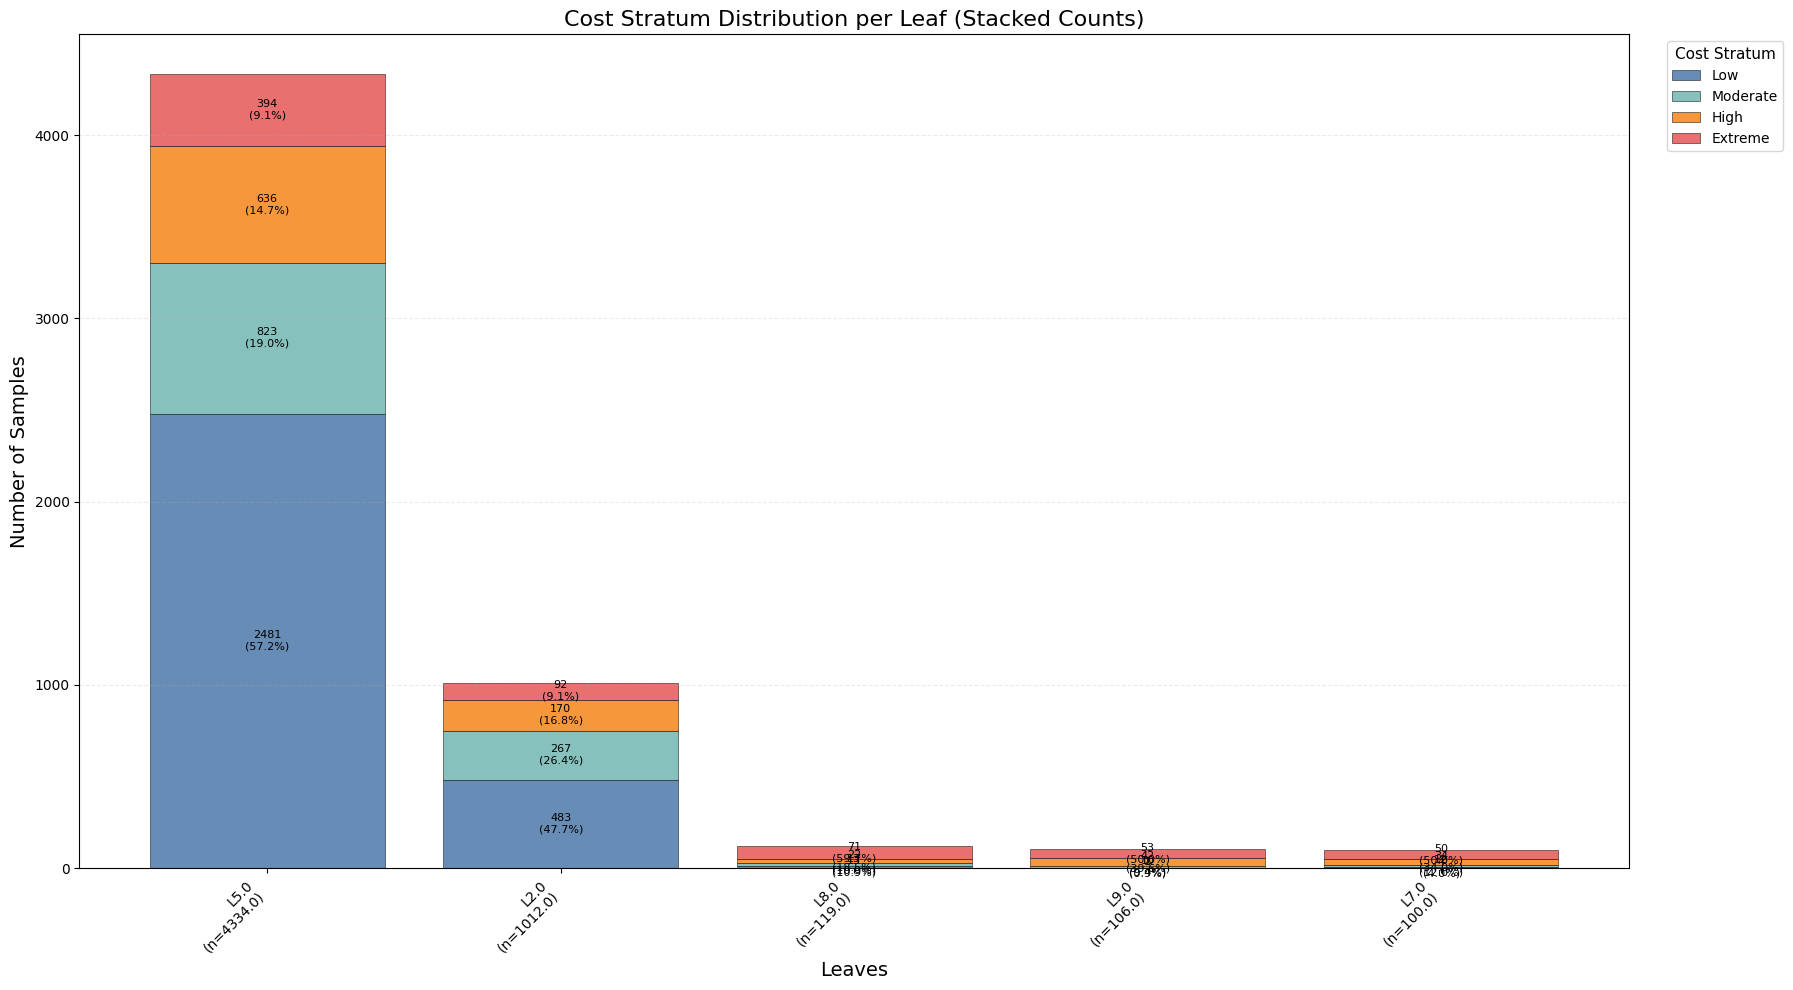


LEAF STRATUM SUMMARY
Overall class distribution across all leaves:
  Stratum 0 (Low): 2982 (52.6%)
  Stratum 1 (Moderate): 1125 (19.8%)
  Stratum 2 (High): 904 (15.9%)
  Stratum 3 (Extreme): 660 (11.6%)

Dominant stratum frequency among selected leaves:
  Stratum 3 (Extreme): 3 leaves (60.0%)
  Stratum 0 (Low): 2 leaves (40.0%)

Mean predicted vs actual rates (overall):
 Stratum    Label  Actual_Rate  Pred_Rate
       0      Low        0.526      0.979
       1 Moderate        0.198      0.021
       2     High        0.159      0.000
       3  Extreme        0.116      0.000


In [63]:
labels = {0: 'Low', 1: 'Moderate', 2: 'High', 3: 'Extreme'}
colors = {0: '#4C78A8', 1: '#72B7B2', 2: '#F58518', 3: '#E45756'}
leaf_stats_df = oct_leaf_analysis.visualize_leaf_cost_distributions_4class(
    undersampled_training_data,
    strata_labels=labels,
    strata_colors=colors
)


# Evaluate Final Prediction Models

In [64]:
X_test = test_pd[feature_cols]
y_test = test_pd['highcost_gt_200000']

## Vanilla model M0

In [49]:
_,_,train_val_pd,val_pd = model_pipeline.train_test_split_enrol(train_pd, target_col = "cost_stratum_2018",test_size=0.3,verbose=False)
X_train_final = train_val_pd[feature_cols]
y_train_final = train_val_pd["highcost_gt_200000"]
X_val = val_pd[feature_cols]
y_val = val_pd['highcost_gt_200000']
print(X_train_final.shape)




(16435, 78)


In [ ]:
import model_IAI
importlib.reload(model_IAI)
from model_IAI import evaluate_binary_oct
best_model, best_params, results_df = finetune_oct(
    X_train_final, y_train_final,X_val, y_val,categorical_cols=CAT_COLUMNS, numeric_cols=TRUE_NUM_COLUMNS,
    depths=[3,5,7,9],
    minbuckets=[100,120,150,200],
    cps=[0.001, 0.01, 0.1]
)

print("Best params:", best_params)
print(results_df)
best_model
X_test_M0 = evaluate_binary_oct(best_M0,X_test,y_test,preprocessor,feature_names)

NameError: name 'best_M0' is not defined

## Model M2

In [65]:
_,_,undersampled_train,undersampled_val = model_pipeline.train_test_split_enrol(undersampled_training_data, target_col = "cost_stratum_2018",test_size=0.3,verbose=False)
X_train_undersampled = undersampled_train[feature_cols]
y_train_undersampled = undersampled_train["highcost_gt_200000"]
X_val_undersampled = undersampled_val[feature_cols]
y_val_undersampled = undersampled_val['highcost_gt_200000']
print(X_train_undersampled.shape)

minbuckets_M2=[50,100,120,150]
cps_M2=[0.00001,5e-4, 0.0001,5e-3, 0.001, 0.01, 0.1]
depths_M2=[5,7,9]
balanced_model, balanced_params, results_balanced ,preprocessor, feature_names = finetune_oct(
    X_train_undersampled, y_train_undersampled,X_val_undersampled, y_val_undersampled,categorical_cols=CAT_COLUMNS, numeric_cols=TRUE_NUM_COLUMNS,
    depths=depths_M2,
    minbuckets=minbuckets_M2,
    cps=cps_M2
)

print("Best params:", balanced_params)
print(results_balanced)
balanced_model



(3969, 78)
→ Building preprocessor:
   • OneHotEncoder on: ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'cost_pattern_2017', 'cost_stability_2017', 'lab_monitoring_intensity']
   • StandardScaler on: ['2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_ckd_claims', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_ckd_claims', '2017Q3_direct_ckd_cost', '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost', '2017Q4_ckd_cost', '2017Q4_ckd_claims', '2017Q4_direct_ckd_cost', '2017Q4_procedure_ckd_cost', '2017Q4_comorbidity_ckd_cost', 'ckd_cost_trend_2017', 'ckd_cost_volatility_2017', 'ckd_cost_deriv_Q1_Q2_2017', 'ckd_cost_deriv_Q2_Q3_2017', 'ckd_cost_deriv_Q3_Q4_2017', 'avg_quarterly_derivative_2017', 'quarterly_std_2017', 'quarterly_skewness_2017', 'quarterly_kurtosis_2017', 'quarterly_cv_2017', 'quarterly_max_2017', 'quart

Fitted OptimalTreeClassifier:
  1) Split: 2017Q4_max_ckd_stage < 5.5
    2) Split: util_2017 < 1.592
      3) Predict: 0 (91.63%), [3163,289], 3452 points, error 0.08372
      4) Split: 2017Q4_ckd_cost < 0.09485
        5) Predict: 0 (86.52%), [77,12], 89 points, error 0.1348
        6) Predict: 1 (66.67%), [22,44], 66 points, error 0.3333
    7) Split: quarterly_max_2017 < 0.248
      8) Predict: 0 (84.65%), [182,33], 215 points, error 0.1535
      9) Split: 2017Q3_procedure_ckd_cost < -0.3626
        10) Predict: 0 (72.00%), [36,14], 50 points, error 0.28
        11) Predict: 1 (72.16%), [27,70], 97 points, error 0.2784

In [66]:
import model_IAI
importlib.reload(model_IAI)
from model_IAI import evaluate_binary_oct
print("Balanced model: ", evaluate_binary_oct(balanced_model,X_test,y_test,preprocessor,feature_names))
#print("Best M2 refitted: ", evaluate_binary_oct(best_M2,X_test,y_test,preprocessor,feature_names))


Test dataset for OCT application: 10,063 samples
✓ Test data preprocessing completed: (10063, 90)
✓ Feature names: ['INCOME_LEVEL_1', 'INCOME_LEVEL_2', 'INCOME_LEVEL_3', 'AGEGRP_2', 'AGEGRP_3', 'AGEGRP_4', 'AGEGRP_5', 'SEX_2', 'REGION_2', 'REGION_3', 'REGION_4', 'REGION_5', 'cost_pattern_2017_early_heavy', 'cost_pattern_2017_late_heavy', 'cost_stability_2017_moderate', 'cost_stability_2017_stable', 'lab_monitoring_intensity_Low', 'lab_monitoring_intensity_Minimal', 'lab_monitoring_intensity_Moderate', '2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_ckd_claims', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_ckd_claims', '2017Q3_direct_ckd_cost', '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost', '2017Q4_ckd_cost', '2017Q4_ckd_claims', '2017Q4_direct_ckd_cost', '2017Q4_procedure_ckd_cost', '2017Q4_comorbidity_

In [40]:
from imblearn.under_sampling import RandomUnderSampler

X = df_prebalanced.drop(columns=['highcost_gt_200000'])
y = df_prebalanced['highcost_gt_200000']

rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X, y)


undersampled_rus = pd.concat([X_res, y_res], axis=1)
print(undersampled_rus['cost_stratum_2018'].value_counts())
_,_,rus_train,rus_val = model_pipeline.train_test_split_enrol(undersampled_rus, target_col = "cost_stratum_2018",test_size=0.3,verbose=False)
X_train_rus = rus_train[feature_cols]
y_train_rus = rus_train["highcost_gt_200000"]
X_val_rus = rus_val[feature_cols]
y_val_rus = rus_val['highcost_gt_200000']
print(X_train_rus.shape)
rus_model, rus_params, results_rus = finetune_oct(
    X_train_rus, y_train_rus,X_val_rus, y_val_rus,categorical_cols=CAT_COLUMNS, numeric_cols=TRUE_NUM_COLUMNS,
    depths=depths_M2,
    minbuckets=minbuckets_M2,
    cps=cps_M2
)

print("Best params:", rus_params)
print(results_rus)
rus_model



cost_stratum_2018
3    660
0    598
1     33
2     29
Name: count, dtype: int64
(924, 78)
→ Building preprocessor:
   • OneHotEncoder on: ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'cost_pattern_2017', 'cost_stability_2017', 'lab_monitoring_intensity']
   • StandardScaler on: ['2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_ckd_claims', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_ckd_claims', '2017Q3_direct_ckd_cost', '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost', '2017Q4_ckd_cost', '2017Q4_ckd_claims', '2017Q4_direct_ckd_cost', '2017Q4_procedure_ckd_cost', '2017Q4_comorbidity_ckd_cost', 'ckd_cost_trend_2017', 'ckd_cost_volatility_2017', 'ckd_cost_deriv_Q1_Q2_2017', 'ckd_cost_deriv_Q2_Q3_2017', 'ckd_cost_deriv_Q3_Q4_2017', 'avg_quarterly_derivative_2017', 'quarterly_std_2017', 'quarterly_skewness_2017

Fitted OptimalTreeClassifier:
  1) Split: 2017Q4_procedure_ckd_cost < -0.003668
    2) Split: 2017Q4_ckd_cost < -0.3231
      3) Split: quarterly_max_2017 < -0.4196
        4) Predict: 0 (85.22%), [248,43], 291 points, error 0.1478
        5) Split: stage_2017 < 3.5
          6) Predict: 0 (75.18%), [106,35], 141 points, error 0.2482
          7) Predict: 1 (77.63%), [17,59], 76 points, error 0.2237
      8) Predict: 1 (87.32%), [18,124], 142 points, error 0.1268
    9) Split: has_Acute_Kidney_Failure < 0.5
      10) Split: quarterly_max_2017 < -0.3654
        11) Predict: 0 (66.67%), [36,18], 54 points, error 0.3333
        12) Predict: 1 (78.21%), [17,61], 78 points, error 0.2179
      13) Predict: 1 (85.92%), [20,122], 142 points, error 0.1408

In [ ]:
rus_oct,preprocessor, feature_names = train_oct_with_feature_names(X_train_rus, y_train_rus,
categorical_cols=CAT_COLUMNS, numeric_cols=TRUE_NUM_COLUMNS, 
max_depth=rus_params[0], minbucket=rus_params[1],cp=rus_params[2]
)


X_test_rus = evaluate_binary_oct(rus_oct,X_test,y_test,preprocessor,feature_names)


→ Building preprocessor:
   • OneHotEncoder on: ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'cost_pattern_2017', 'cost_stability_2017', 'lab_monitoring_intensity']
   • StandardScaler on: ['2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_ckd_claims', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_ckd_claims', '2017Q3_direct_ckd_cost', '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost', '2017Q4_ckd_cost', '2017Q4_ckd_claims', '2017Q4_direct_ckd_cost', '2017Q4_procedure_ckd_cost', '2017Q4_comorbidity_ckd_cost', 'ckd_cost_trend_2017', 'ckd_cost_volatility_2017', 'ckd_cost_deriv_Q1_Q2_2017', 'ckd_cost_deriv_Q2_Q3_2017', 'ckd_cost_deriv_Q3_Q4_2017', 'avg_quarterly_derivative_2017', 'quarterly_std_2017', 'quarterly_skewness_2017', 'quarterly_kurtosis_2017', 'quarterly_cv_2017', 'quarterly_max_2017', 'quarterly_min_20

ROCCurve with AUC 0.8416:

 Row │ threshold  tpr       fpr
     │ Float64    Float64   Float64
─────┼────────────────────────────────
   1 │ 1.0        0.0       0.0
   2 │ 0.927083   0.212014  0.0271984
   3 │ 0.869565   0.547703  0.100511
   4 │ 0.735849   0.632509  0.127812
   5 │ 0.715686   0.742049  0.189059
   6 │ 0.553571   0.833922  0.24499
   7 │ 0.263441   0.943463  0.547546
   8 │ 0.0850202  1.0       1.0
   9 │ 0.0        1.0       1.0

# Non-OCT models

In [50]:

# Logistic Regression for binary high-cost prediction
print("Training Logistic Regression model...")
log_pipeline = model_pipeline.get_logistic_pipeline(
    df=X_train_final,categorical_cols=CAT_COLUMNS, numeric_cols=TRUE_NUM_COLUMNS, C=0.1, max_iter=1000,
)
log_pipeline.fit(X_train_final, y_train_final)  # Binary classification

# Random Forest for binary high-cost prediction
print("Training Random Forest model...")
rf_pipeline = model_pipeline.get_random_forest_pipeline(
    df=X_train_final ,categorical_cols=CAT_COLUMNS, numeric_cols=TRUE_NUM_COLUMNS, 
)
rf_pipeline.fit(X_train_final, y_train_final )  # Binary classification

# Gradient Boosting for binary high-cost prediction
print("Training Gradient Boosting model...")
gb_pipeline = model_pipeline.get_histgb_pipeline(
   df=X_train_final ,categorical_cols=CAT_COLUMNS, numeric_cols=TRUE_NUM_COLUMNS, balance_classes = True
)
gb_pipeline.fit(X_train_final, y_train_final)  # Binary classification


Training Logistic Regression model...
→ Building preprocessor:
   • OneHotEncoder on: ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'cost_pattern_2017', 'cost_stability_2017', 'lab_monitoring_intensity']
   • StandardScaler on: ['2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_ckd_claims', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_ckd_claims', '2017Q3_direct_ckd_cost', '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost', '2017Q4_ckd_cost', '2017Q4_ckd_claims', '2017Q4_direct_ckd_cost', '2017Q4_procedure_ckd_cost', '2017Q4_comorbidity_ckd_cost', 'ckd_cost_trend_2017', 'ckd_cost_volatility_2017', 'ckd_cost_deriv_Q1_Q2_2017', 'ckd_cost_deriv_Q2_Q3_2017', 'ckd_cost_deriv_Q3_Q4_2017', 'avg_quarterly_derivative_2017', 'quarterly_std_2017', 'quarterly_skewness_2017', 'quarterly_kurtosis_2017', 'quarterly_cv_2017', '

/Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/lib/python3.11/site-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['INCOME_LEVEL', 'AGEGRP',
                                                   'SEX', 'REGION',
                                                   'cost_pattern_2017',
                                                   'cost_stability_2017',
                                                   'lab_monitoring_intensity']),
                                                 ('num', StandardScaler(),
                                                  ['2017Q1_ckd_cost',
                                                   '2017Q1_ckd_claims',
                                                   '2017Q1_direct_ckd_cost',
                                                   '201...
                                                   'ckd_cost_trend_2017',
                                                   'ckd_cost_volatility_2017',
                                                   'ckd_cost_deriv_Q1_Q2_2017',
                                                   'ckd_cost_deriv_Q2_Q3_2017',
                                                   'ckd_cost_deriv_Q3_Q4_2017',
                                                   'avg_quarterly_derivative_2017',
                                                   'quarterly_std_2017',
                                                   'quarterly_skewness_2017',
                                                   'quarterly_kurtosis_2017',
                                                   'quarterly_cv_2017', ...])])),
                ('classifier',
                 HistGradientBoostingClassifier(class_weight='balanced',
                                                max_iter=200,
                                                random_state=42))])

In [51]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# Logistic Regression
y_pred_log = log_pipeline.predict(X_test)
y_prob_log = log_pipeline.predict_proba(X_test)[:, 1]

# Random Forest
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

# Gradient Boosting
y_pred_gb = gb_pipeline.predict(X_test)
y_prob_gb = gb_pipeline.predict_proba(X_test)[:, 1]


In [67]:

# Logistic Regression for binary high-cost prediction
print("Training Logistic Regression model...")
log_pipeline2 = model_pipeline.get_logistic_pipeline(
    df=X_train_undersampled,categorical_cols=CAT_COLUMNS, numeric_cols=TRUE_NUM_COLUMNS, C=0.1, max_iter=1000,
)
log_pipeline2.fit(X_train_undersampled, y_train_undersampled)  # Binary classification

# Random Forest for binary high-cost prediction
print("Training Random Forest model...")
rf_pipeline2 = model_pipeline.get_random_forest_pipeline(
    df=X_train_undersampled ,categorical_cols=CAT_COLUMNS, numeric_cols=TRUE_NUM_COLUMNS, 
)
rf_pipeline2.fit(X_train_undersampled, y_train_undersampled )  # Binary classification

# Gradient Boosting for binary high-cost prediction
print("Training Gradient Boosting model...")
gb_pipeline2 = model_pipeline.get_histgb_pipeline(
   df=X_train_undersampled ,categorical_cols=CAT_COLUMNS, numeric_cols=TRUE_NUM_COLUMNS, balance_classes = True
)
gb_pipeline2.fit(X_train_undersampled, y_train_undersampled)  # Binary classification


Training Logistic Regression model...
→ Building preprocessor:
   • OneHotEncoder on: ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'cost_pattern_2017', 'cost_stability_2017', 'lab_monitoring_intensity']
   • StandardScaler on: ['2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_ckd_claims', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_ckd_claims', '2017Q3_direct_ckd_cost', '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost', '2017Q4_ckd_cost', '2017Q4_ckd_claims', '2017Q4_direct_ckd_cost', '2017Q4_procedure_ckd_cost', '2017Q4_comorbidity_ckd_cost', 'ckd_cost_trend_2017', 'ckd_cost_volatility_2017', 'ckd_cost_deriv_Q1_Q2_2017', 'ckd_cost_deriv_Q2_Q3_2017', 'ckd_cost_deriv_Q3_Q4_2017', 'avg_quarterly_derivative_2017', 'quarterly_std_2017', 'quarterly_skewness_2017', 'quarterly_kurtosis_2017', 'quarterly_cv_2017', '

/Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/lib/python3.11/site-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['INCOME_LEVEL', 'AGEGRP',
                                                   'SEX', 'REGION',
                                                   'cost_pattern_2017',
                                                   'cost_stability_2017',
                                                   'lab_monitoring_intensity']),
                                                 ('num', StandardScaler(),
                                                  ['2017Q1_ckd_cost',
                                                   '2017Q1_ckd_claims',
                                                   '2017Q1_direct_ckd_cost',
                                                   '201...
                                                   'ckd_cost_trend_2017',
                                                   'ckd_cost_volatility_2017',
                                                   'ckd_cost_deriv_Q1_Q2_2017',
                                                   'ckd_cost_deriv_Q2_Q3_2017',
                                                   'ckd_cost_deriv_Q3_Q4_2017',
                                                   'avg_quarterly_derivative_2017',
                                                   'quarterly_std_2017',
                                                   'quarterly_skewness_2017',
                                                   'quarterly_kurtosis_2017',
                                                   'quarterly_cv_2017', ...])])),
                ('classifier',
                 HistGradientBoostingClassifier(class_weight='balanced',
                                                max_iter=200,
                                                random_state=42))])

In [68]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# Logistic Regression
y_pred_log2 = log_pipeline2.predict(X_test)
y_prob_log2 = log_pipeline2.predict_proba(X_test)[:, 1]

# Random Forest
y_pred_rf2 = rf_pipeline2.predict(X_test)
y_prob_rf2 = rf_pipeline2.predict_proba(X_test)[:, 1]

# Gradient Boosting
y_pred_gb2 = gb_pipeline2.predict(X_test)
y_prob_gb2 = gb_pipeline2.predict_proba(X_test)[:, 1]




In [54]:
from model_pipeline import evaluate_model_auc
for model in [gb_pipeline, gb_pipeline2]:
    evaluate_model_auc(model, X_test, y_test)

Evaluating model with highcost_cutoff:  4
Binary AUC: 0.876
Classification Report:
              precision    recall  f1-score   support

           0      0.981     0.977     0.979      9780
           1      0.300     0.346     0.321       283

    accuracy                          0.959     10063
   macro avg      0.640     0.661     0.650     10063
weighted avg      0.962     0.959     0.960     10063

Confusion Matrix:
[[9551  229]
 [ 185   98]]
Evaluating model with highcost_cutoff:  4
Binary AUC: 0.618
Classification Report:
              precision    recall  f1-score   support

           0      0.976     0.940     0.957      9780
           1      0.084     0.191     0.116       283

    accuracy                          0.919     10063
   macro avg      0.530     0.565     0.537     10063
weighted avg      0.951     0.919     0.934     10063

Confusion Matrix:
[[9189  591]
 [ 229   54]]
